In [1]:
##################### Plot Initial Conditions ######################
# The purpose of this script is to plot the initial conditions for
# the idealized Beaufort shelfbreak jet model. These will include
# vertical cross sections and surface things. 
#
# Notes:
# - This script heavily uses code written by Dylan Schlichting
#
#####################################################################

In [2]:
# Load in the packages
import numpy as np
import cartopy
import glob
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
from matplotlib.colors import LogNorm
from matplotlib.colors import SymLogNorm
from matplotlib.ticker import LogFormatterExponent
import warnings
import xarray as xr
import os
import xroms
from glob import glob
from joblib import Parallel, delayed
warnings.filterwarnings("ignore") #turns off annoying warnings

In [3]:
# Load in the initial conditions 
# 500 m case, all runs
ini_conds = xr.open_dataset('/global/cfs/cdirs/m4572/dylan617/beaufort_jet/runs/ini_ice_500_m.nc')

In [4]:
# Load in the grid
grid = xr.open_dataset('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet/grd_500_m.nc')

In [5]:
grid.x_rho

<xarray.DataArray 'x_rho' (eta_rho: 1002, xi_rho: 402)> Size: 3MB
[402804 values with dtype=float64]
Dimensions without coordinates: eta_rho, xi_rho

In [6]:
# Make coordinates for plotting
x_rho = grid.x_rho / 1000
x_u = grid.x_u / 1000
y_rho = grid.y_rho / 1000 
y_u = grid.y_u / 1000

In [7]:
ini_conds

<xarray.Dataset> Size: 699MB
Dimensions:             (s_rho: 40, eta_rho: 1002, xi_rho: 402, ocean_time: 1,
                         eta_u: 1002, xi_u: 401, eta_v: 1001, xi_v: 402)
Coordinates:
  * s_rho               (s_rho) float64 320B -0.9875 -0.9625 ... -0.0375 -0.0125
  * xi_rho              (xi_rho) int64 3kB 0 1 2 3 4 5 ... 397 398 399 400 401
  * eta_rho             (eta_rho) int64 8kB 0 1 2 3 4 ... 997 998 999 1000 1001
  * ocean_time          (ocean_time) timedelta64[ns] 8B 00:00:00
Dimensions without coordinates: eta_u, xi_u, eta_v, xi_v
Data variables: (12/22)
    temp                (s_rho, eta_rho, xi_rho) float64 129MB ...
    salt                (s_rho, eta_rho, xi_rho) float64 129MB ...
    u                   (ocean_time, s_rho, eta_u, xi_u) float64 129MB ...
    v                   (ocean_time, s_rho, eta_v, xi_v) float64 129MB ...
    zeta                (ocean_time, eta_rho, xi_rho) float64 3MB ...
    ubar                (ocean_time, eta_u, xi_u) float64 3MB ...
    ...                  ...
    ice_sst             (ocean_time, eta_rho, xi_rho) float64 3MB ...
    ice_Sxx             (ocean_time, eta_rho, xi_rho) float64 3MB ...
    ice_Sxy             (ocean_time, eta_rho, xi_rho) float64 3MB ...
    ice_Syy             (ocean_time, eta_rho, xi_rho) float64 3MB ...
    Uice                (ocean_time, eta_u, xi_u) float64 3MB ...
    Vice                (ocean_time, eta_v, xi_v) float64 3MB ...
Attributes:
    type:         ROMS Ini file
    Description:  Initial conditions for ideal shelf
    Author:       Dylan Schlichting
    Created:      2025-12-29T14:52:59.098776

Text(0.5, 1.0, 'Along-Shore Velocity')

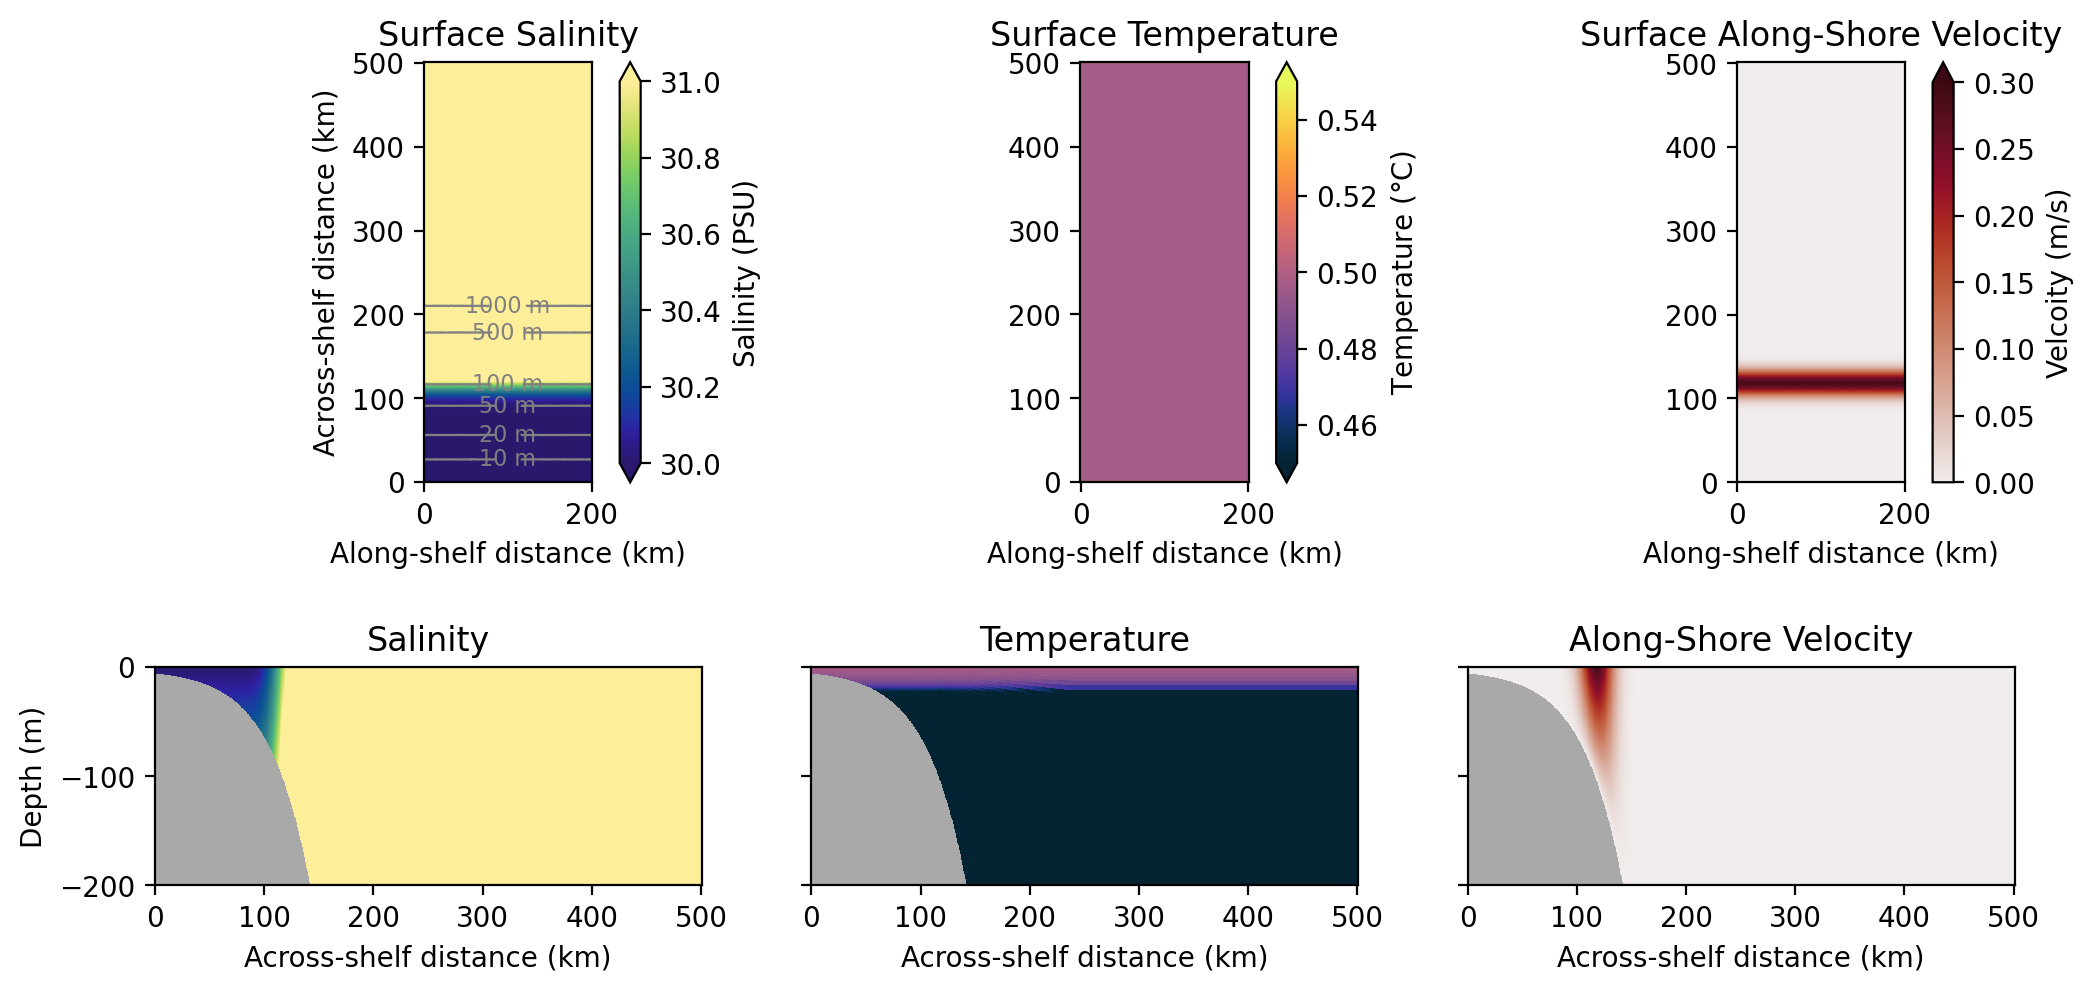

In [8]:
# Make a plot of surface and vertical things 

# Set the levels for things
lev_salt = np.arange(29,32,0.1)


# Make the figure
fig, ax = plt.subplots(2, 3, dpi=200, figsize=(12,6))

# Surface salinity
m1 = ax[0,0].pcolormesh(grid.x_rho/1000, grid.y_rho/1000, ini_conds.salt[-1,:,:], cmap=cmo.haline,
                        vmin=30, vmax=31)
fig.colorbar(m1, ax=ax[0,0], label='Salinity (PSU)', extend='both')
# Contours for bathymetry
positions = [(100, 10),(100,60),(100,90),(100,140),(100,160),(100,210)]
cs = ax[0,0].contour(grid.x_rho/1000, grid.y_rho/1000, grid.h, levels=[10, 20, 50, 100, 500, 1000],
                colors='gray', linewidths=0.8)
ax[0,0].clabel(cs, fmt='%d m', manual=positions, inline=True, fontsize=8, colors='gray')

# Surface temperature 
m2 = ax[0,1].pcolormesh(grid.x_rho/1000, grid.y_rho/1000, ini_conds.temp[-1,:,:], cmap=cmo.thermal,
                        vmin=0.45, vmax=0.55)
fig.colorbar(m2, ax=ax[0,1], label='Temperature ($\degree$C)', extend='both')

# Surface along-shore velocity 
m3 = ax[0,2].pcolormesh(grid.x_u/1000, grid.y_u/1000, ini_conds.u[0,-1,:,:], cmap=cmo.amp,
                        vmin=0, vmax=0.3)
fig.colorbar(m3, ax=ax[0,2], label='Velcoity (m/s)', extend='max')

# Set consistent axis limits
for r in range(3):
    ax[0,r].set_xlabel('Along-shelf distance (km)')
    ax[0,r].set_aspect(1)

# Vertical cross sections
# Salinity
m4 = ax[1,0].pcolormesh(grid.y_rho[:,201]/1000, ini_conds.z_rho[0,:,:,201], ini_conds.salt[:,:,201], cmap=cmo.haline,
                        vmin=30, vmax=31)
#fig.colorbar(m4, ax=ax[1,0], label='(PSU)', extend='both')

# Temperature 
m5 = ax[1,1].pcolormesh(grid.y_rho[:,201]/1000, ini_conds.z_rho[0,:,:,201], ini_conds.temp[:,:,201], cmap=cmo.thermal,
                        vmin=0.45, vmax=0.55)
#fig.colorbar(m5, ax=ax[1,1], label='($\degree$C)', extend='both')

# U
m6 = ax[1,2].pcolormesh(grid.y_u[:,201]/1000, ini_conds.z_rho[0,:,:,201], ini_conds.u[0,:,:,201], cmap=cmo.amp,
                        vmin=0, vmax=0.3)
#fig.colorbar(m6, ax=ax[1,2], label='Velcoity (m/s)', extend='max')

for rr in range(3):
    # Set y lim
    ax[1,rr].set_ylim(-200,0)
    ax[1,rr].set_facecolor('darkgray')
    ax[1,rr].set_aspect(1.0)

# Label the axes
ax[0,0].set_ylabel('Across-shelf distance (km)')
ax[1,0].set_ylabel('Depth (m)')
ax[1,0].set_xlabel('Across-shelf distance (km)')
ax[1,1].set_xlabel('Across-shelf distance (km)')
ax[1,2].set_xlabel('Across-shelf distance (km)')
ax[1,1].set_yticklabels('')
ax[1,2].set_yticklabels('')

# Give the subplots titles
ax[0,0].set_title('Surface Salinity')
ax[0,1].set_title('Surface Temperature')
ax[0,2].set_title('Surface Along-Shore Velocity')
ax[1,0].set_title('Salinity')
ax[1,1].set_title('Temperature')
ax[1,2].set_title('Along-Shore Velocity')

# fig.canvas.draw()

# for c in range(3):
#     top_pos = ax[0, c].get_position()
#     bottom_pos = ax[1, c].get_position()

#     top_center = top_pos.y0 + top_pos.height / 2
#     bottom_center = bottom_pos.y0 + bottom_pos.height / 2

#     dy = top_center - bottom_center

#     # Shift bottom axes by dy (relative move)
#     ax[1, c].set_position([
#         bottom_pos.x0,
#         bottom_pos.y0 + dy,
#         bottom_pos.width,
#         bottom_pos.height
#     ])


# 

In [32]:
ini_conds

<xarray.Dataset> Size: 699MB
Dimensions:             (s_rho: 40, eta_rho: 1002, xi_rho: 402, ocean_time: 1,
                         eta_u: 1002, xi_u: 401, eta_v: 1001, xi_v: 402)
Coordinates:
  * s_rho               (s_rho) float64 320B -0.9875 -0.9625 ... -0.0375 -0.0125
  * xi_rho              (xi_rho) int64 3kB 0 1 2 3 4 5 ... 397 398 399 400 401
  * eta_rho             (eta_rho) int64 8kB 0 1 2 3 4 ... 997 998 999 1000 1001
  * ocean_time          (ocean_time) timedelta64[ns] 8B 00:00:00
Dimensions without coordinates: eta_u, xi_u, eta_v, xi_v
Data variables: (12/22)
    temp                (s_rho, eta_rho, xi_rho) float64 129MB ...
    salt                (s_rho, eta_rho, xi_rho) float64 129MB ...
    u                   (ocean_time, s_rho, eta_u, xi_u) float64 129MB ...
    v                   (ocean_time, s_rho, eta_v, xi_v) float64 129MB ...
    zeta                (ocean_time, eta_rho, xi_rho) float64 3MB ...
    ubar                (ocean_time, eta_u, xi_u) float64 3MB ...
    ...                  ...
    ice_sst             (ocean_time, eta_rho, xi_rho) float64 3MB ...
    ice_Sxx             (ocean_time, eta_rho, xi_rho) float64 3MB ...
    ice_Sxy             (ocean_time, eta_rho, xi_rho) float64 3MB ...
    ice_Syy             (ocean_time, eta_rho, xi_rho) float64 3MB ...
    Uice                (ocean_time, eta_u, xi_u) float64 3MB ...
    Vice                (ocean_time, eta_v, xi_v) float64 3MB ...
Attributes:
    type:         ROMS Ini file
    Description:  Initial conditions for ideal shelf
    Author:       Dylan Schlichting
    Created:      2025-12-29T14:52:59.098776

In [33]:
# Calculate density so we can add isopycnals 
# to the cross sections 

# Calculate density in the domain to use...or just
# for the transect if this causes the kernel to crash 
# Calculate density again but using linear equation of state 
# Set the coefficients/reference values from ROMS output
R0 = 1025 # kg/m3
T0 = 0.5 # Celsius
S0 =  31 # PSU/nondimensional
T_coeff = 0.00017 # 1/Celsius
S_coeff = 0.00076 # 1/nondimensional

# Now calculate density
ini_rho = R0 * (1 - (T_coeff*(ini_conds.temp-T0)) + (S_coeff*(ini_conds.salt-S0)))


In [51]:
np.max(ini_rho)

<xarray.DataArray ()> Size: 8B
array(1030.13042092)

In [36]:
np.shape(ini_rho)

(40, 1002, 402)

Text(0.594, 0.12, 'c)')

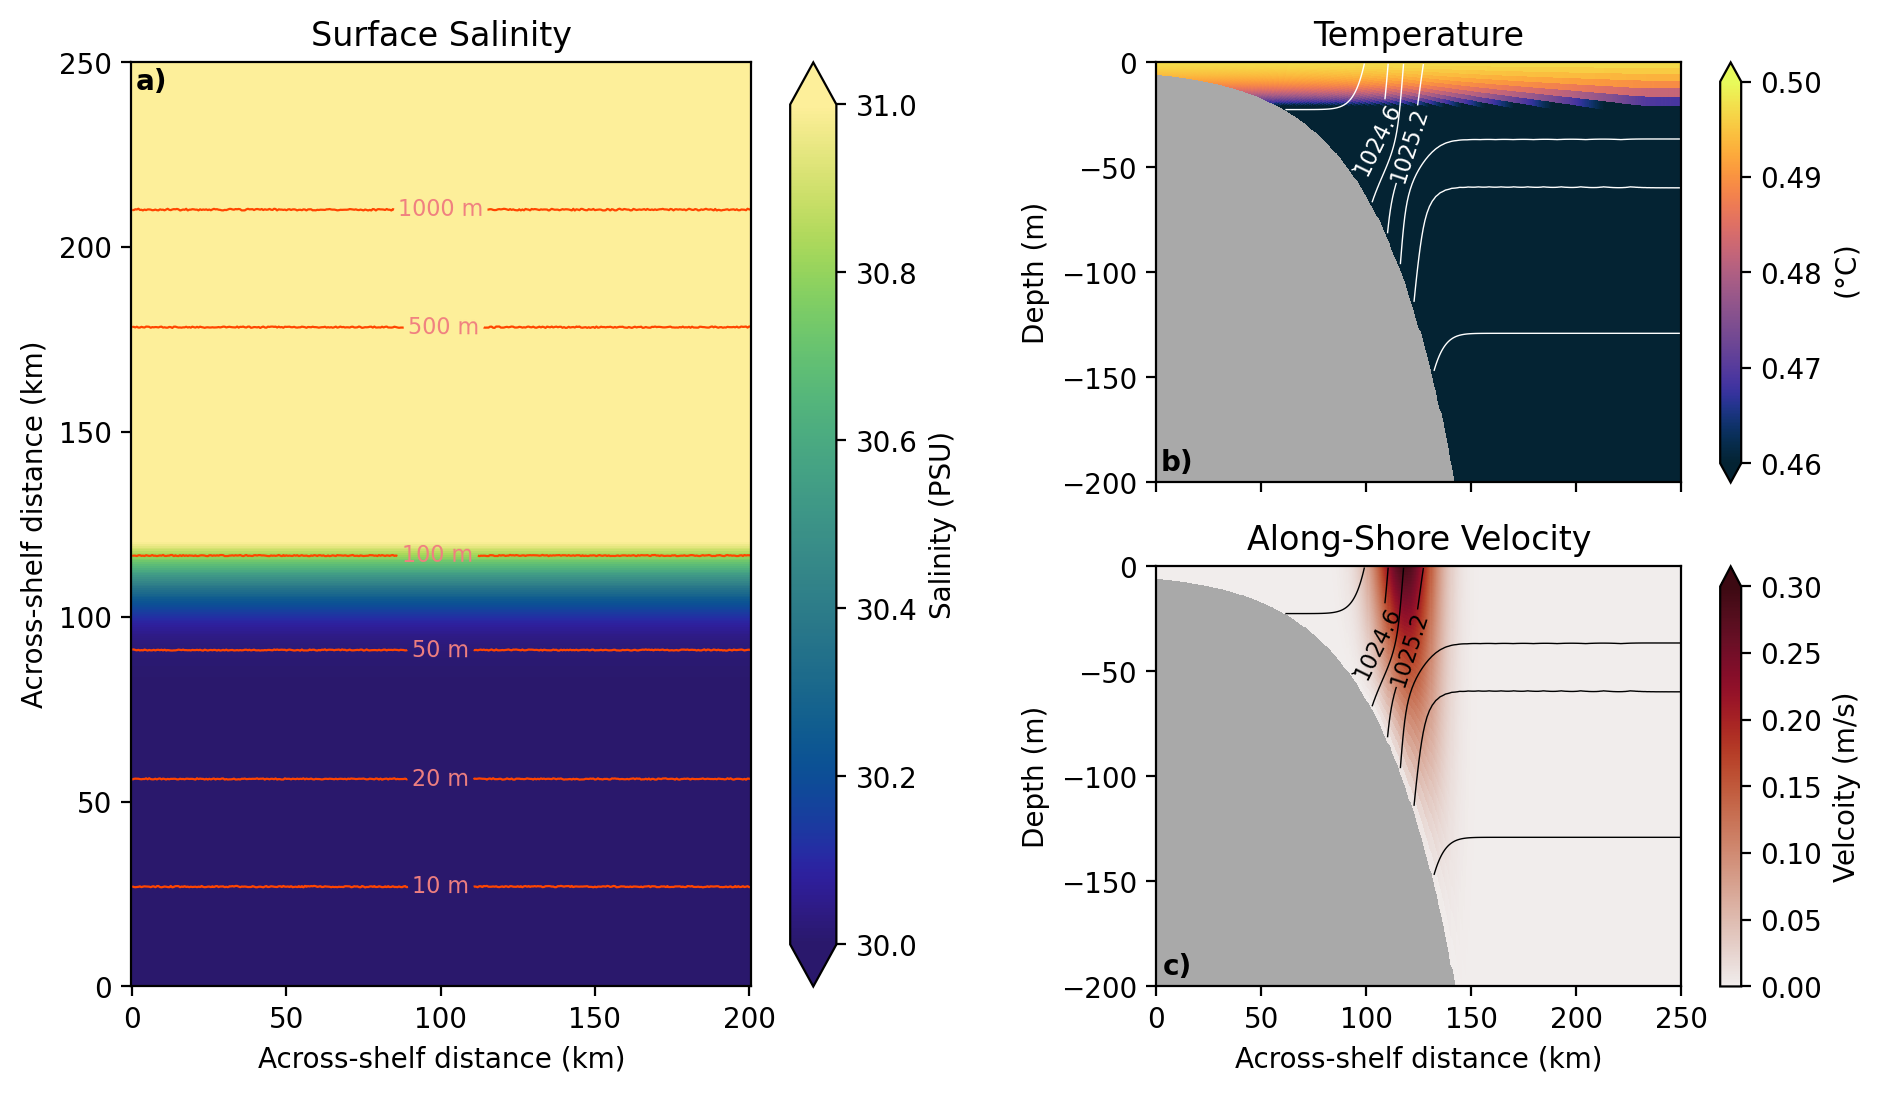

In [95]:
# Make a plot that just has surface salinity 
# and then the transects for the other variables 

# Set the levels for things
lev_salt = np.arange(29,32,0.1)

# Set density levels
lev_dens = np.arange(1024.0, 1030.0, 0.3)
label_levels = np.arange(1024, 1030, 1.0)

# Make the figure
fig = plt.figure(dpi=200, figsize=(11,6))

gs = fig.add_gridspec(2,2)
ax1 = fig.add_subplot(gs[:,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,1])

# Set axis limits
ax2.set_ylim(-200,0)
ax2.set_xlim(0,250)
ax2.set_facecolor('darkgray')
ax2.set_aspect(1.0)
ax3.set_ylim(-200,0)
ax3.set_xlim(0,250)
ax3.set_facecolor('darkgray')
ax3.set_aspect(1.0)

# Surface salinity
m1 = ax1.pcolormesh(grid.x_rho/1000, grid.y_rho/1000, ini_conds.salt[-1,:,:], cmap=cmo.haline,
                        vmin=30, vmax=31)
fig.colorbar(m1, ax=ax1, label='Salinity (PSU)', extend='both')
# Contours for bathymetry
positions = [(100, 10),(100,60),(100,90),(100,140),(100,160),(100,210)]
cs = ax1.contour(grid.x_rho/1000, grid.y_rho/1000, grid.h, levels=[10, 20, 50, 100, 500, 1000],
                colors='orangered', linewidths=0.8)
ax1.clabel(cs, fmt='%d m', manual=positions, inline=True, fontsize=8, colors='lightcoral')
ax1.set_ylim(0,250)

# Vertical cross sections
# Temperature 
m5 = ax2.pcolormesh(grid.y_rho[:,201]/1000, ini_conds.z_rho[0,:,:,201], ini_conds.temp[:,:,201], cmap=cmo.thermal,
                        vmin=0.46, vmax=0.50)
fig.colorbar(m5, ax=ax2, label='($\degree$C)', extend='both')
# Plot density contours
y_sec = grid.y_rho[:, 201]
y_2d = np.array([y_sec]*40)                          
c1 = ax2.contour(y_2d/1000, ini_conds.z_rho[0,:,:,201], ini_rho[:,:,201],
        levels=lev_dens, colors='white', linewidths=0.5)
ax2.clabel(c1, levels=c1.levels[::2], inline=True, inline_spacing=2, fmt='%1.1f', fontsize=8)

# U
m6 = ax3.pcolormesh(grid.y_u[:,201]/1000, ini_conds.z_rho[0,:,:,201], ini_conds.u[0,:,:,201], cmap=cmo.amp,
                        vmin=0, vmax=0.3)
fig.colorbar(m6, ax=ax3, label='Velcoity (m/s)', extend='max')
# Plot denisty conoturs
c2 = ax3.contour(y_2d/1000, ini_conds.z_rho[0,:,:,201], ini_rho[:,:,201],
        levels=lev_dens, colors='black', linewidths=0.5)
ax3.clabel(c2, levels=c2.levels[::2], inline=True, inline_spacing=2, fmt='%1.1f', fontsize=8)

# Label the axes
ax1.set_ylabel('Across-shelf distance (km)')
ax1.set_xlabel('Across-shelf distance (km)')
ax1.set_title('Surface Salinity')
ax2.set_ylabel('Depth (m)')
#ax2.set_xlabel('Across-shelf distance (km)')
ax2.set_xticklabels('')
ax2.set_title('Temperature')
ax3.set_ylabel('Depth (m)')
ax3.set_xlabel('Across-shelf distance (km)')
ax3.set_title('Along-Shore Velocity')

# Add subplot labels
fig.text(0.127, 0.857, 'a)', color='black', weight='bold')
fig.text(0.593, 0.540, 'b)', color='black', weight='bold')
fig.text(0.594, 0.120, 'c)', color='black', weight='bold')






In [54]:
y_2d[1,:]

array([0.000e+00, 5.000e-01, 1.000e+00, ..., 4.995e+02, 5.000e+02,
       5.005e+02])

In [43]:
ini_conds.z_rho[0,:,:,201].shape[0]

40